# *RNR1* Gene expression and chromatin deconvolution 

Now that we have settled on the VST transformation and fixed the CLOCCS parameters, the deconvolution for RNR1 seems stable. 

There is uncertainty with the combined model, but we can at least start looking at the chromatin deconvolutions in conjuction with the gene expression.



In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [87]:
from src.config import load_combined_yl_vst_gene_expression_config
from src.model import Model
from src.find_gamma import FindOptimalGamma

def plot_and_save_model_config(gene_name, config, model_name, abbreviated=False,
                              gamma=None):
    # TODO: Make the deconvolution runner a class that deconvolves both the gene expression
    # and the chromatin, optionally finds gamma, and saves the resulting output to disk
    # that way we can do this all in one go. For our set of genes
    # then for all of the genes.  ---- Will require some clean up and refactoring and
    # organization, but will make this iterative process smoother.    
    if gamma is not None:
        model = Model(config, gene_name, gamma)
        model.deconvolve()
    else:
        model = Model(config, gene_name, 0)
        find_gamma = FindOptimalGamma(model)
        find_gamma.find_optimal()

    model.plot_deconvolved_gene(abbreviated=abbreviated)
    plt.savefig(f'{save_dir}/{gene_name}_{model_name}.png', dpi=150)
    return model

findOptimal
  ... base_rn = 0.0043
  ... gamma in [0.0001, 0.0010]
  ...  search left, rn_goal = 0.0047, rate = 10.0
  ...  search right, rn_goal = 0.3243, rate = 7446.7
  ... rn range: [0.0127, 0.0224]
  ... search gamma in [0.0001 0.0010] for elbow
  ...   gamma = 0.0001, rn = 0.01274, sn = 37
  ...   gamma = 0.00019, rn = 0.01738, sn = 25.01
  ...   gamma = 0.00028, rn = 0.01844, sn = 24.14
  ...   gamma = 0.00037, rn = 0.01921, sn = 23.75
  ...   gamma = 0.00046, rn = 0.01965, sn = 22.83
  ...   gamma = 0.00055, rn = 0.02028, sn = 23.17
  ...   gamma = 0.00064, rn = 0.02078, sn = 23.15
  ...   gamma = 0.00073, rn = 0.02114, sn = 22.94
  ...   gamma = 0.00082, rn = 0.02152, sn = 22.65
  ...   gamma = 0.00091, rn = 0.02194, sn = 22.37
  ...   gamma = 0.001, rn = 0.02236, sn = 22.1
  ...   gamma = 0.00109, rn = 0.02282, sn = 21.84
The x_grad1 is: [0.00463845 0.00284831 0.00091392 0.00060399 0.00115337 0.00114513
 0.00041981 0.00043845 0.00045909]
The x_grad2 is: [-1.79014195e-03 -1.86

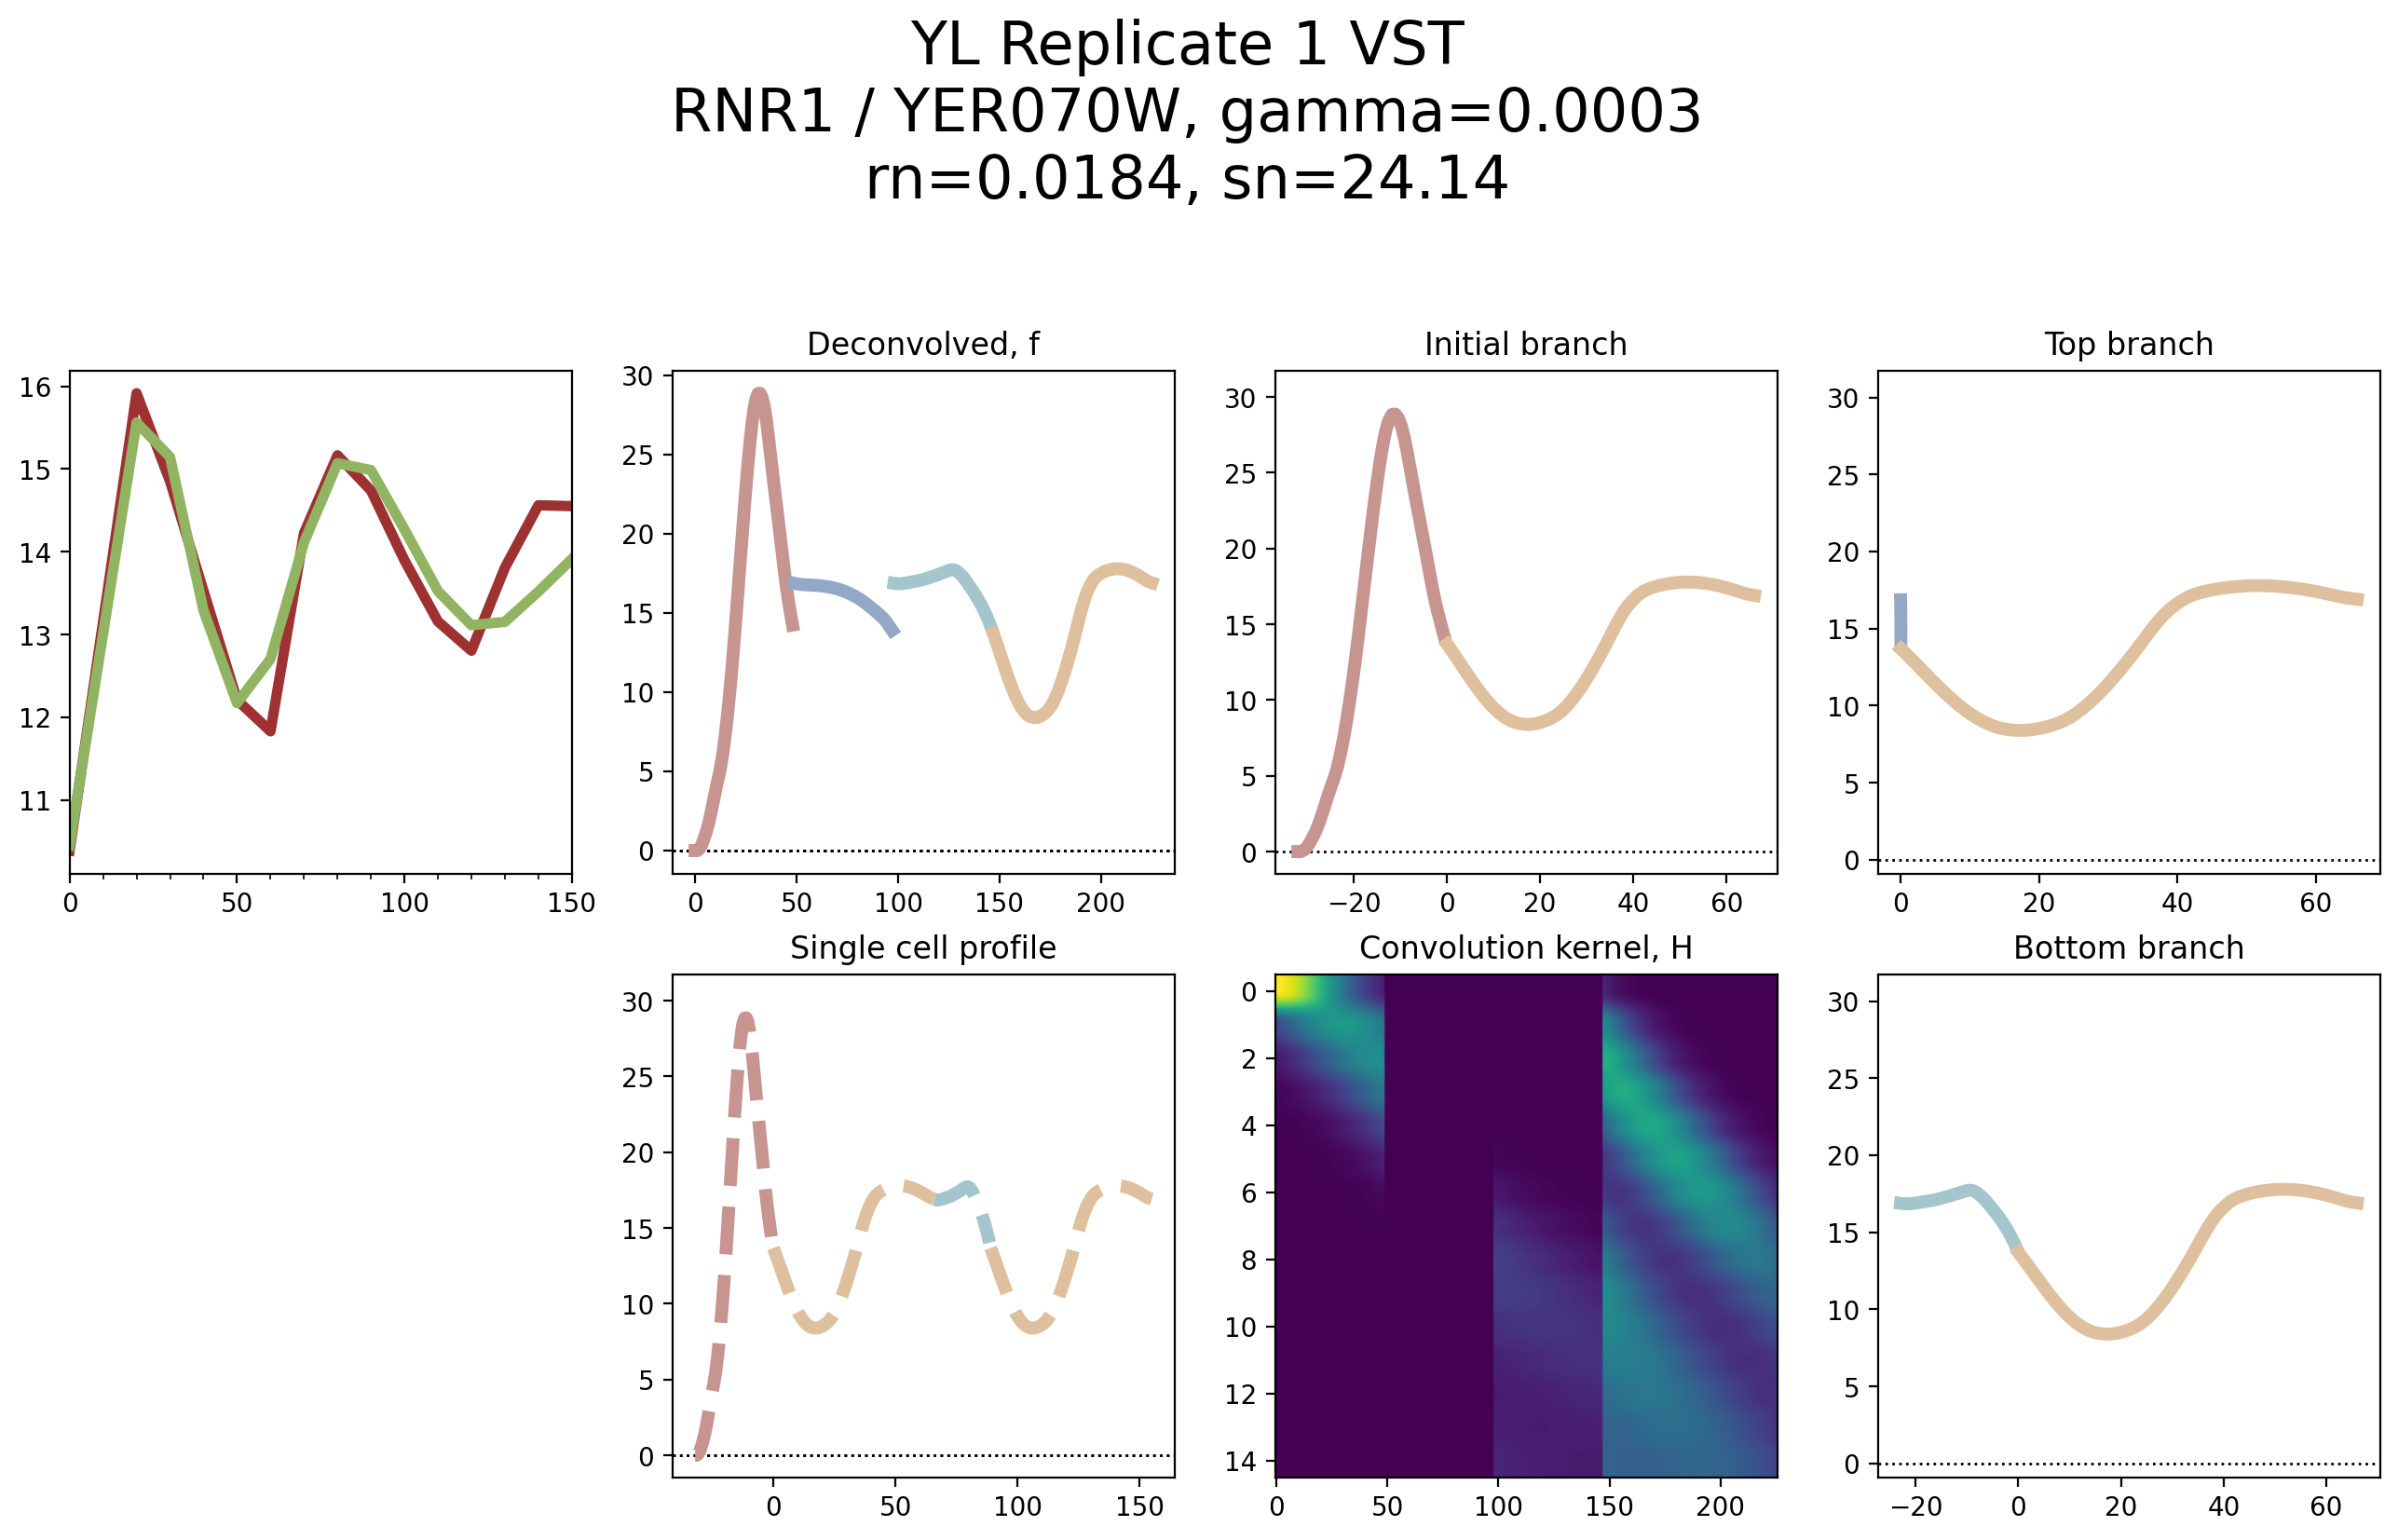

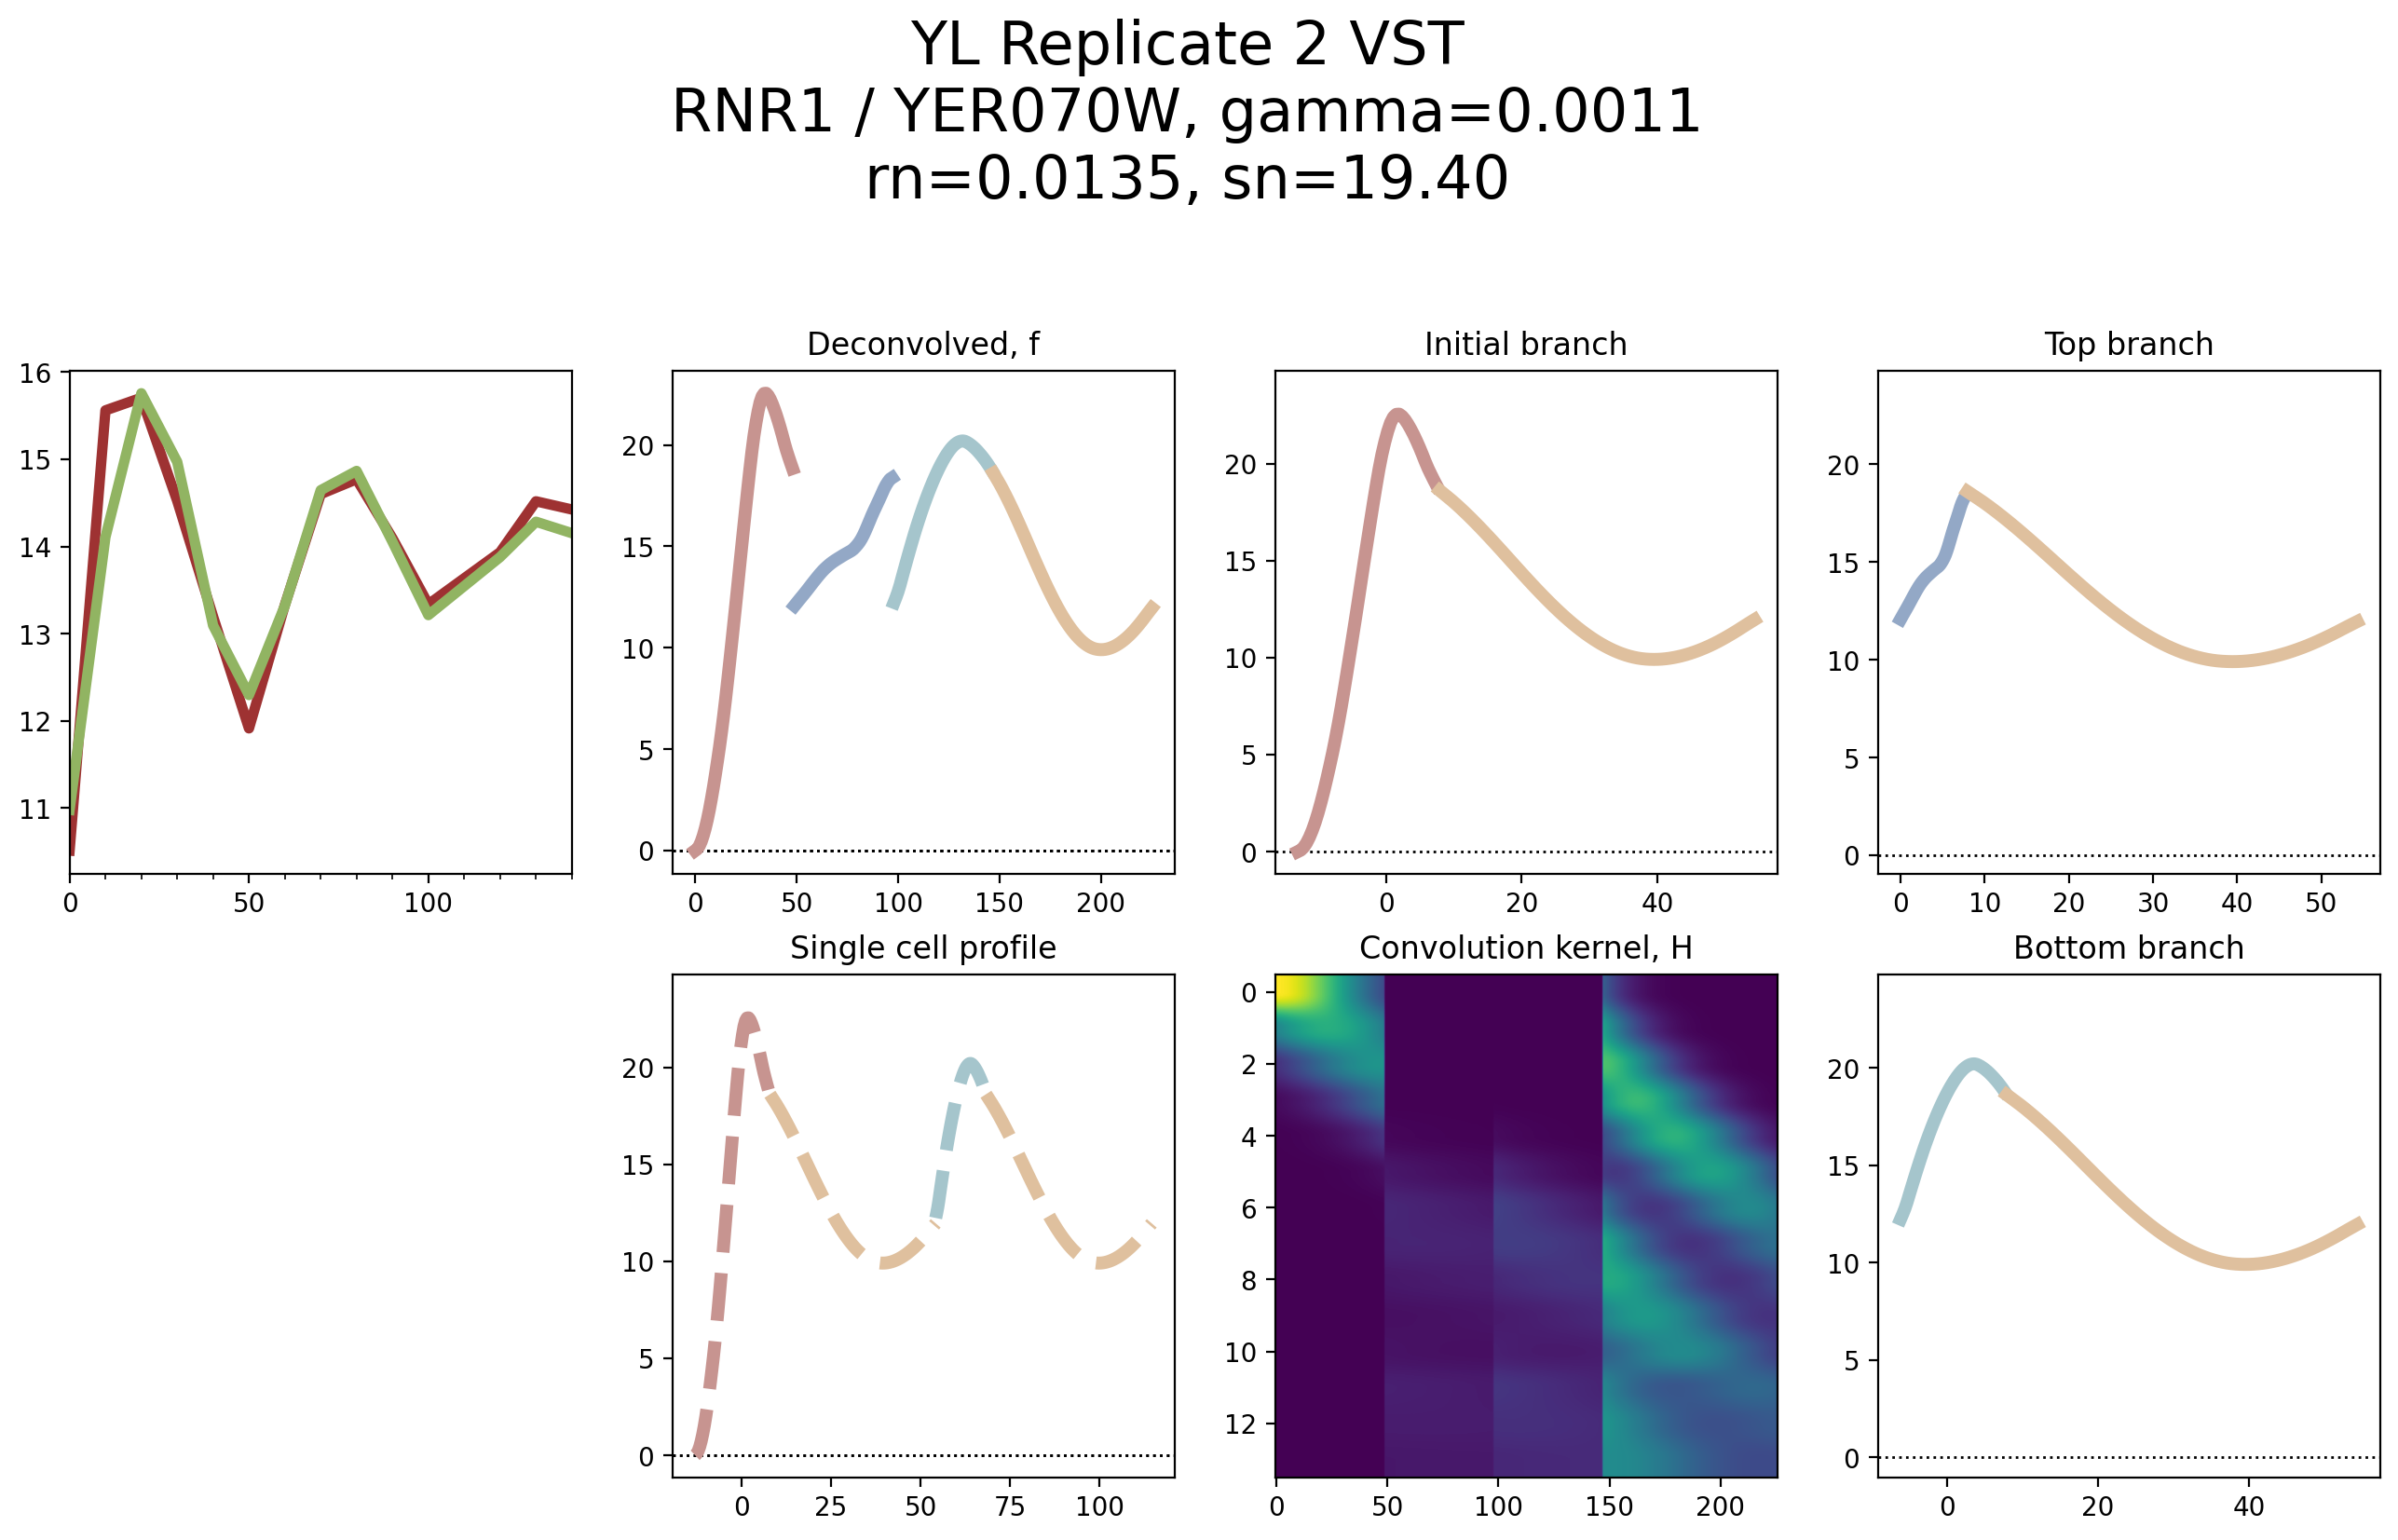

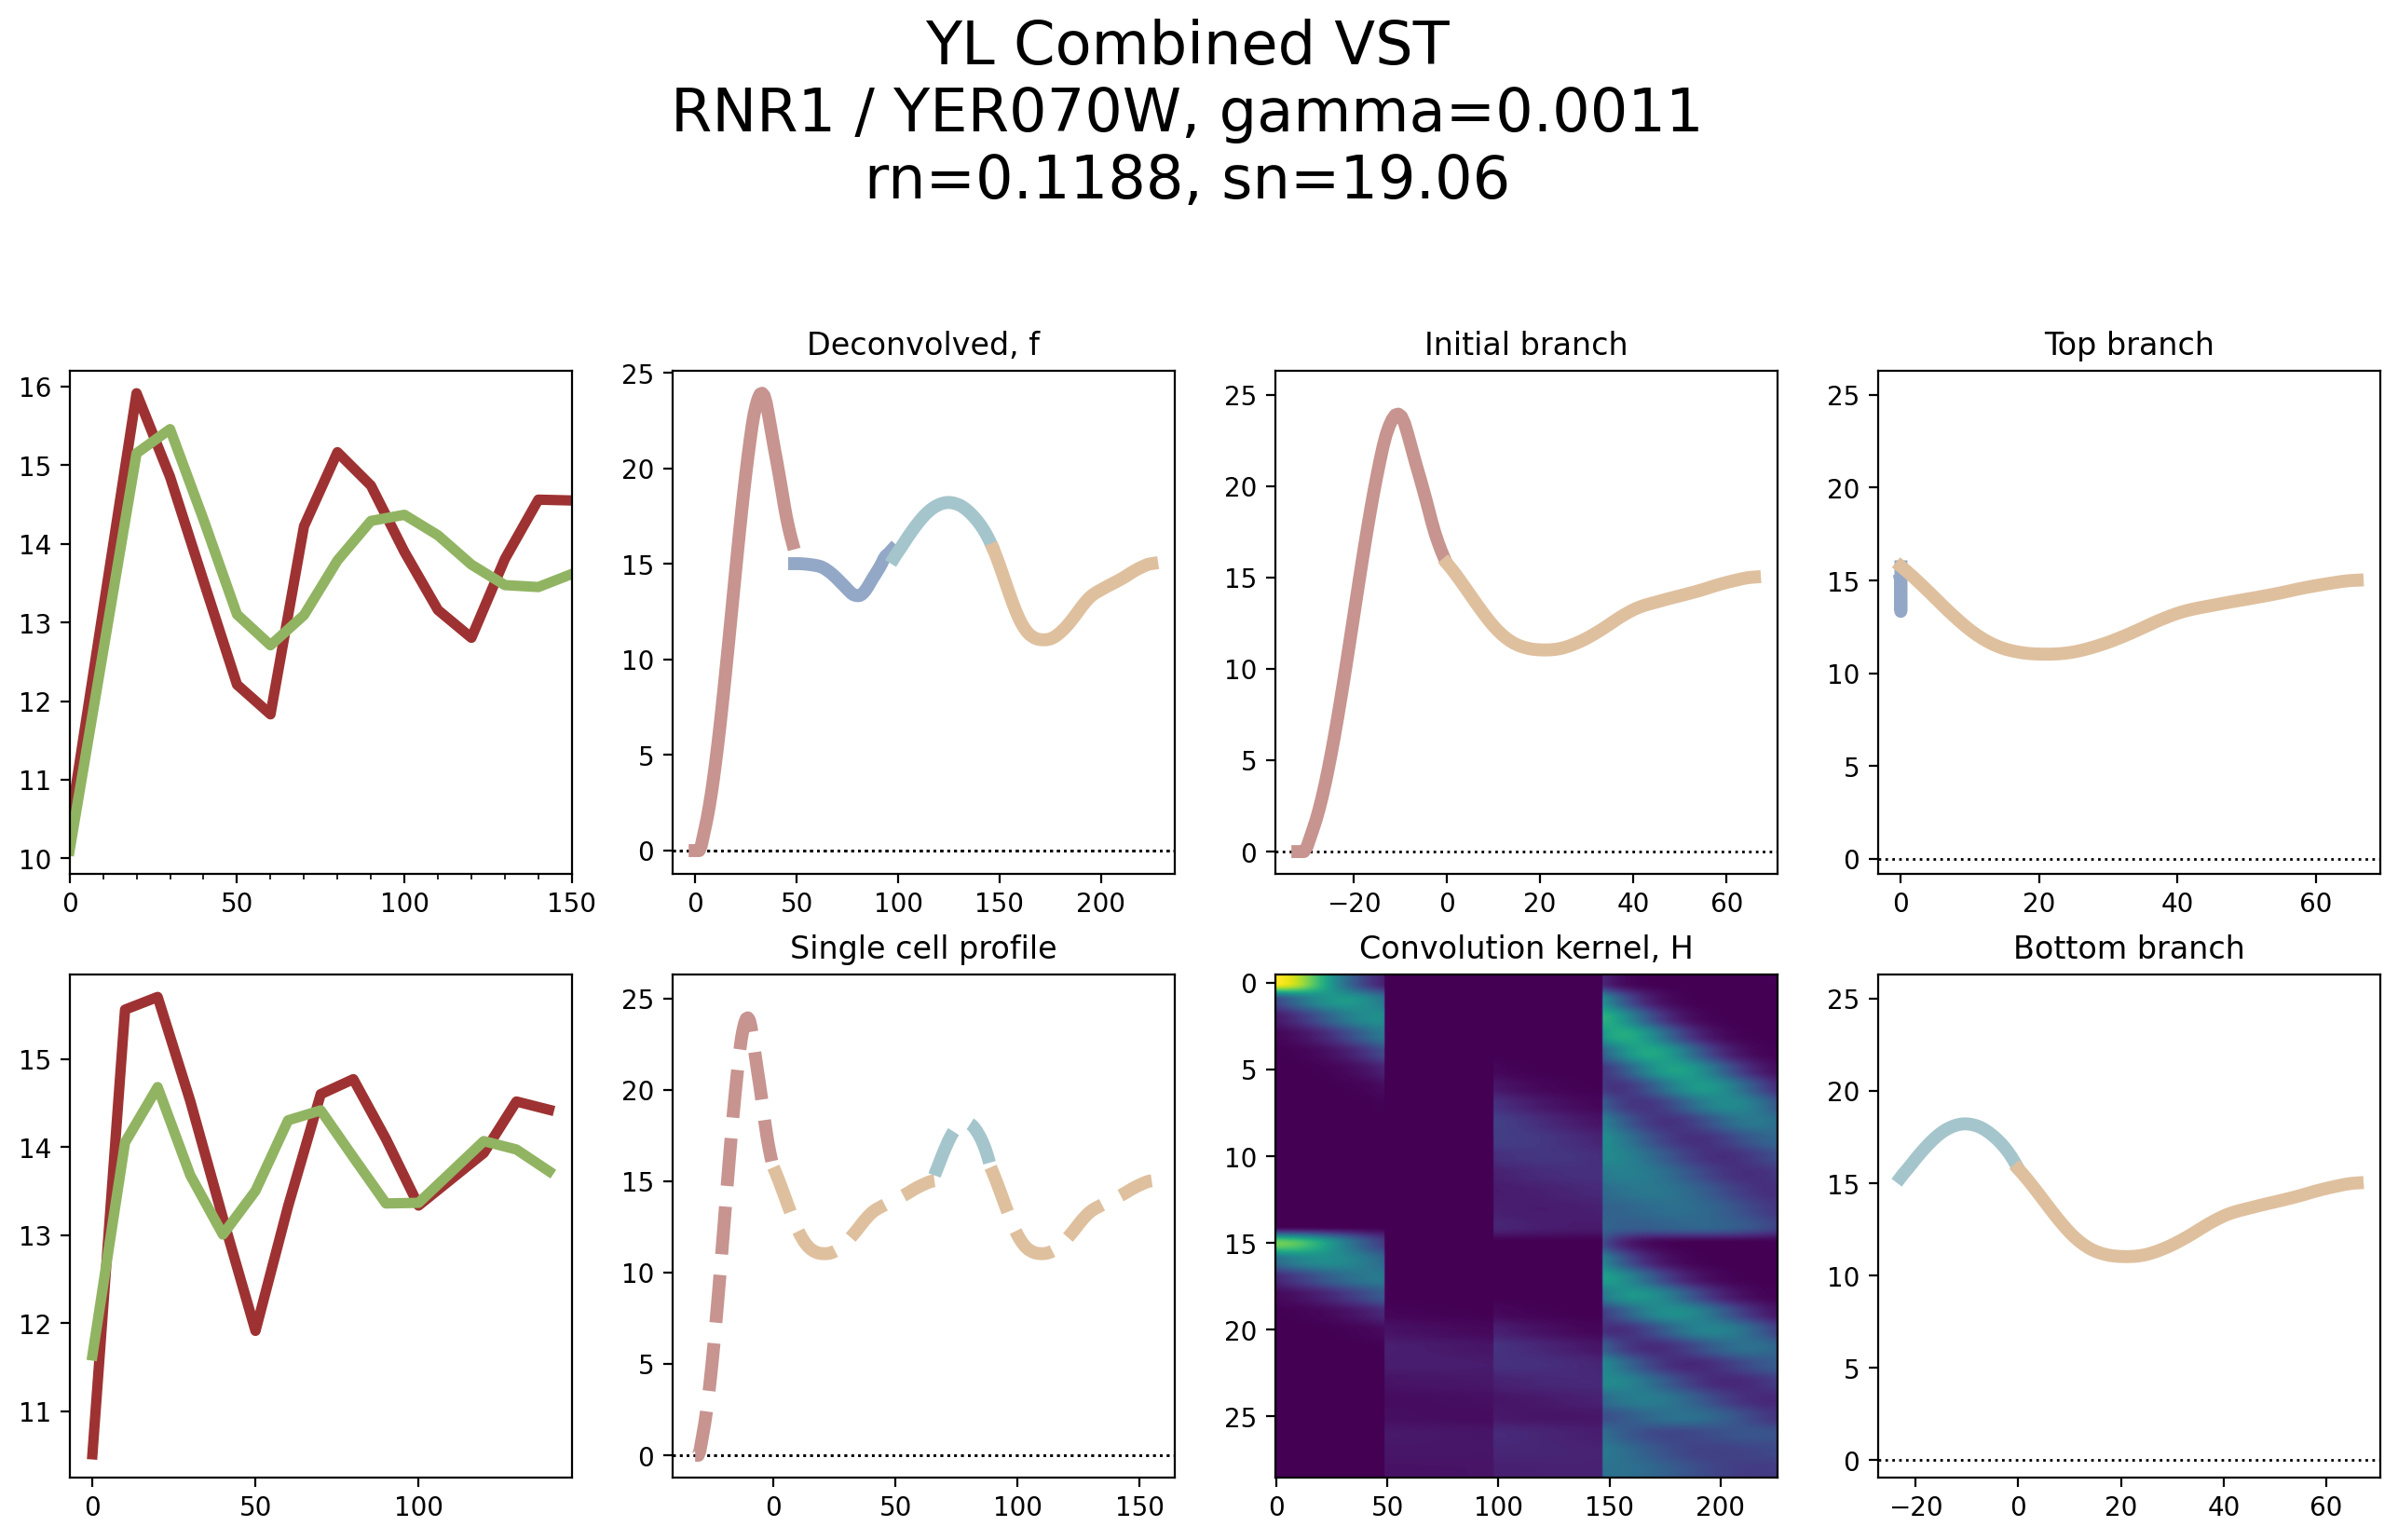

In [108]:
from src.config import load_yl_replicate1_rg1_vst_config, load_yl_replicate2_rg1_vst_config

save_dir = 'output/positive_controls/comparison_rep1_vs_rep2_vs_combined'

gene_name = "RNR1"
config1 = load_yl_replicate1_rg1_vst_config()
config_combined = load_combined_yl_vst_gene_expression_config()
config2 = load_yl_replicate2_rg1_vst_config()

ge_model1 = plot_and_save_model_config(gene_name, config1, 'Replicate 1', 
                                       gamma=None)
ge_model2 = plot_and_save_model_config(gene_name, config2, 'Replicate 2',
                                       gamma=None)
ge_model_combined = plot_and_save_model_config(gene_name, config_combined, 
                                               'Combined', gamma=None)


findOptimal
  ... base_rn = 0.0017
  ... gamma in [0.0001, 0.0010]
  ...  search left, rn_goal = 0.0018, rate = 10.0
  ...  search right, rn_goal = 0.3217, rate = 19372.3
  ... rn range: [0.0090, 0.0121]
  ... search gamma in [0.0001 0.0010] for elbow
  ...   gamma = 0.0001, rn = 0.009022, sn = 17.99
  ...   gamma = 0.00019, rn = 0.009676, sn = 13.79
  ...   gamma = 0.00028, rn = 0.009809, sn = 13.22
  ...   gamma = 0.00037, rn = 0.009997, sn = 12.68
  ...   gamma = 0.00046, rn = 0.01021, sn = 12.3
  ...   gamma = 0.00055, rn = 0.01043, sn = 11.96
  ...   gamma = 0.00064, rn = 0.01069, sn = 11.68
  ...   gamma = 0.00073, rn = 0.01098, sn = 11.38
  ...   gamma = 0.00082, rn = 0.01131, sn = 11.08
  ...   gamma = 0.00091, rn = 0.01168, sn = 10.77
  ...   gamma = 0.001, rn = 0.01207, sn = 10.53
  ...   gamma = 0.00109, rn = 0.0125, sn = 10.29
The x_grad1 is: [0.00065435 0.00039375 0.00016049 0.00020094 0.00021646 0.00023733
 0.00027526 0.00031085 0.0003498  0.0003819  0.00041028 0.00042936

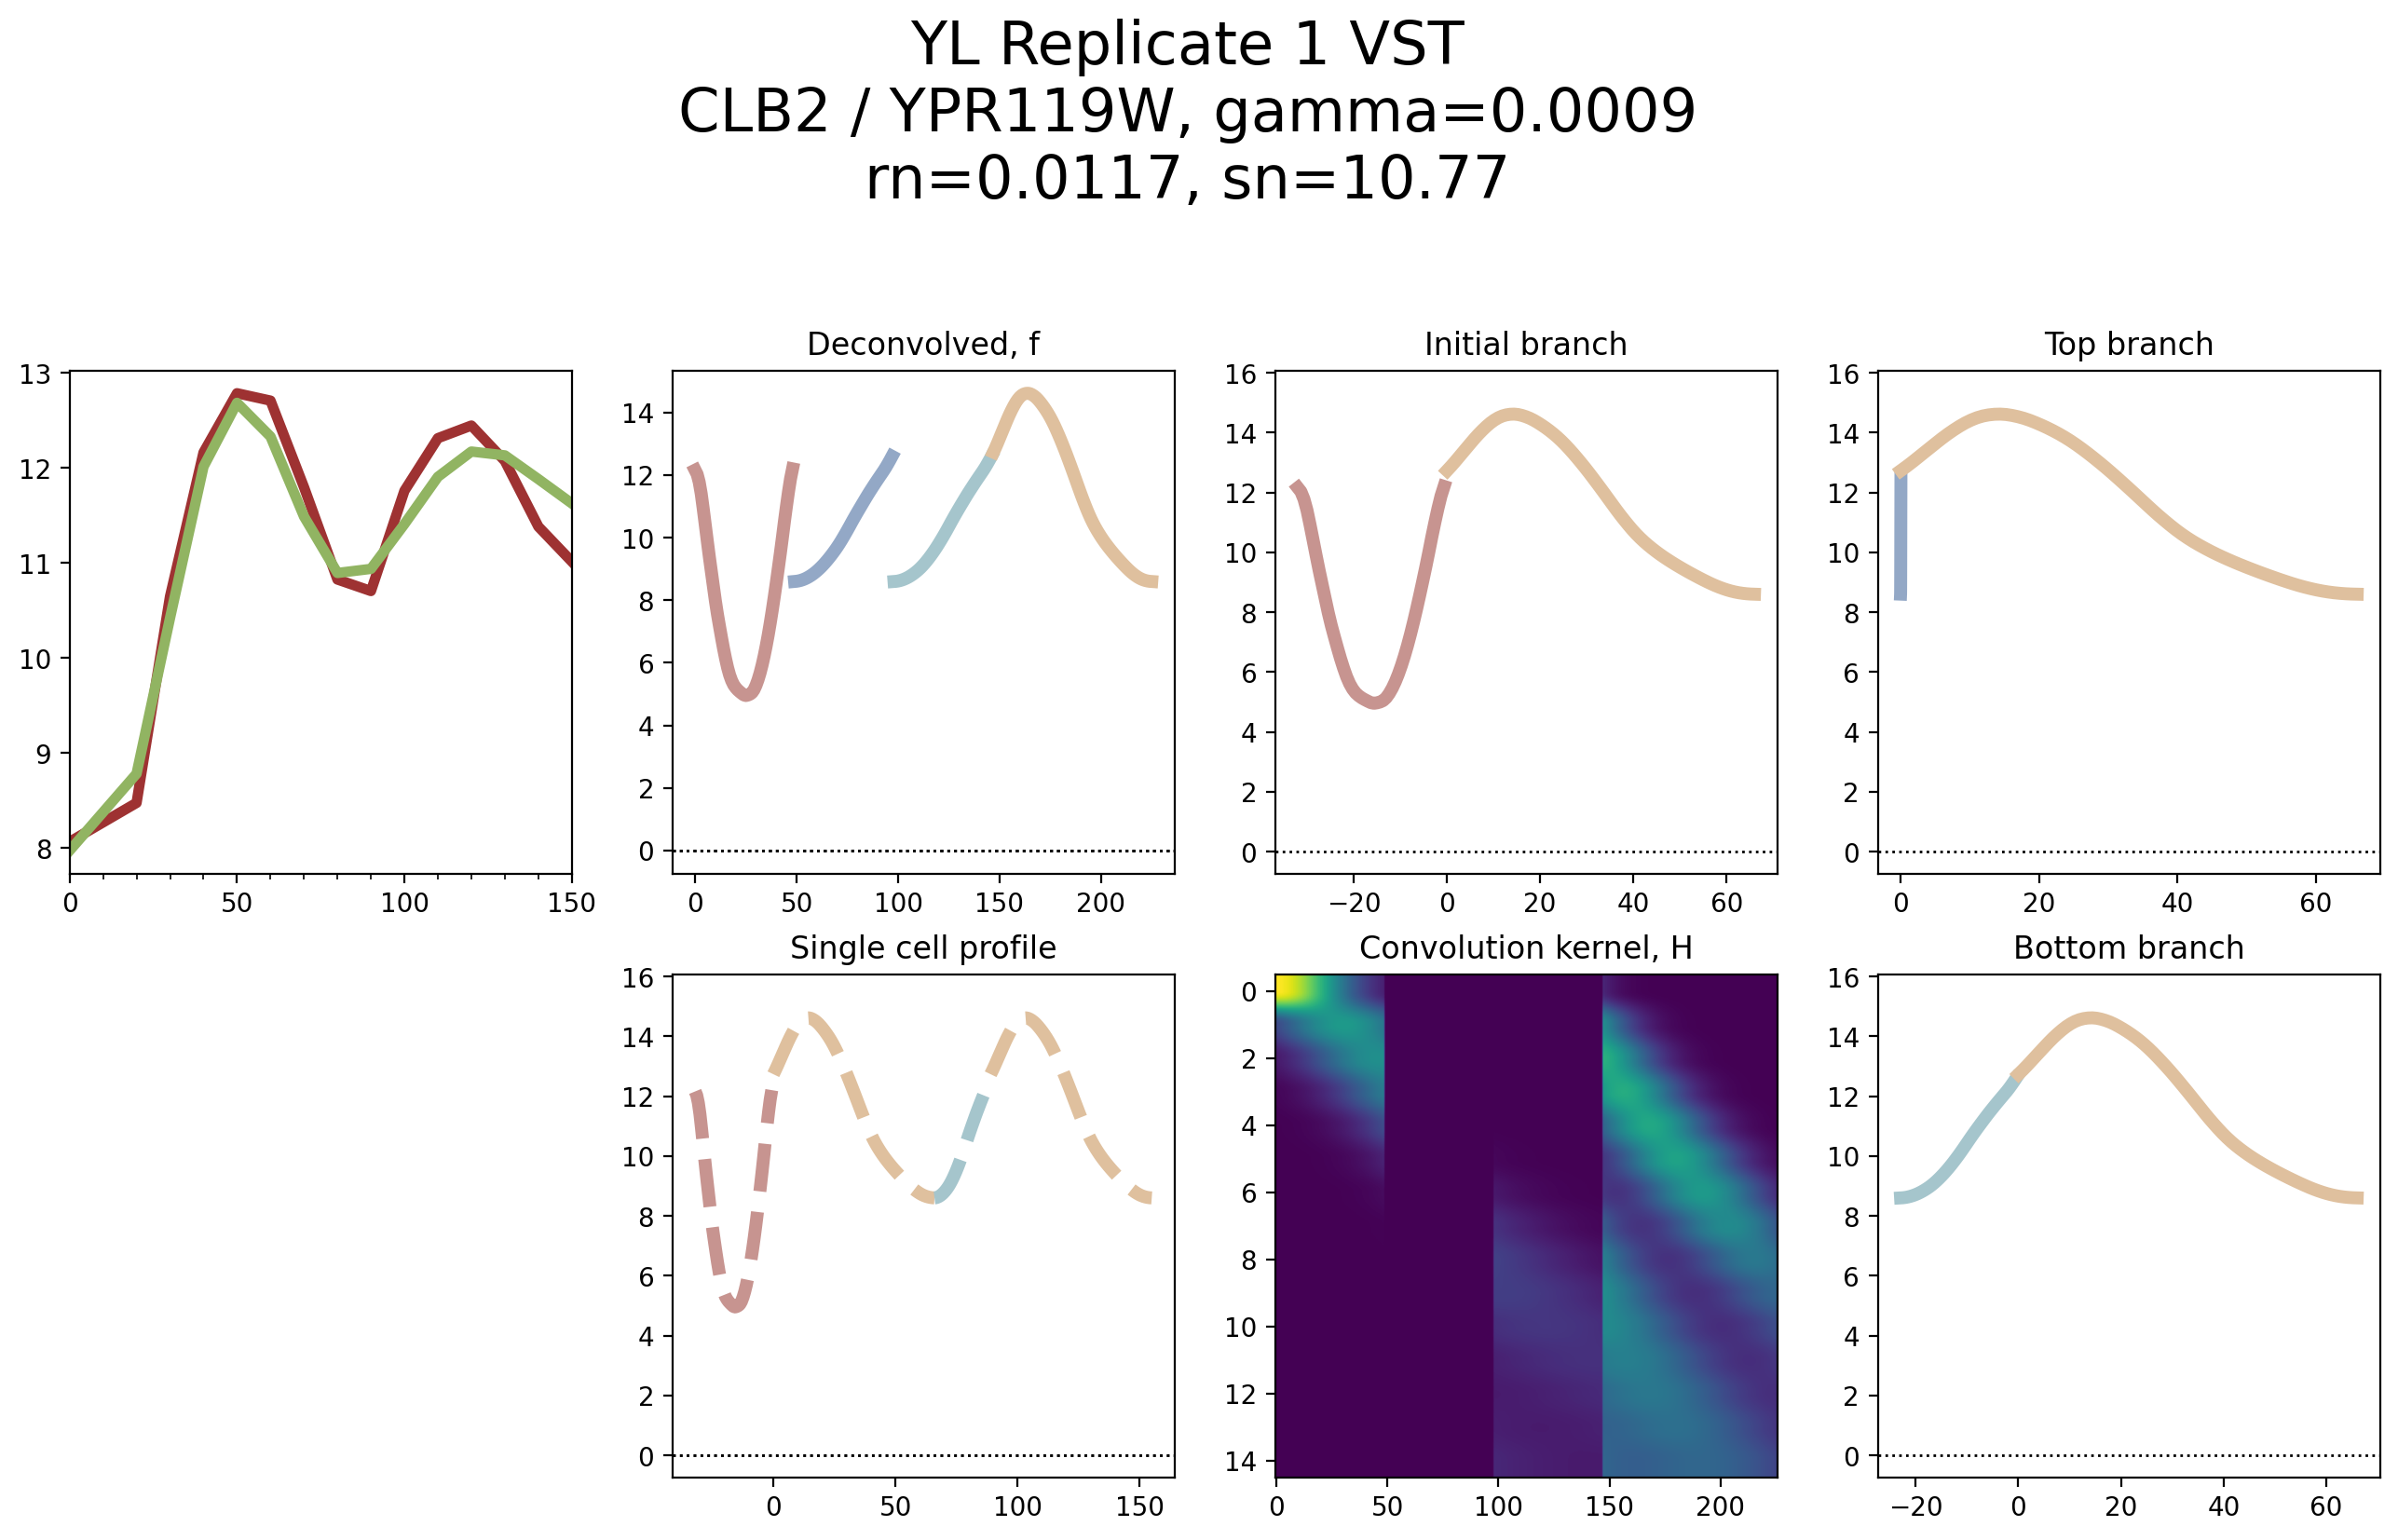

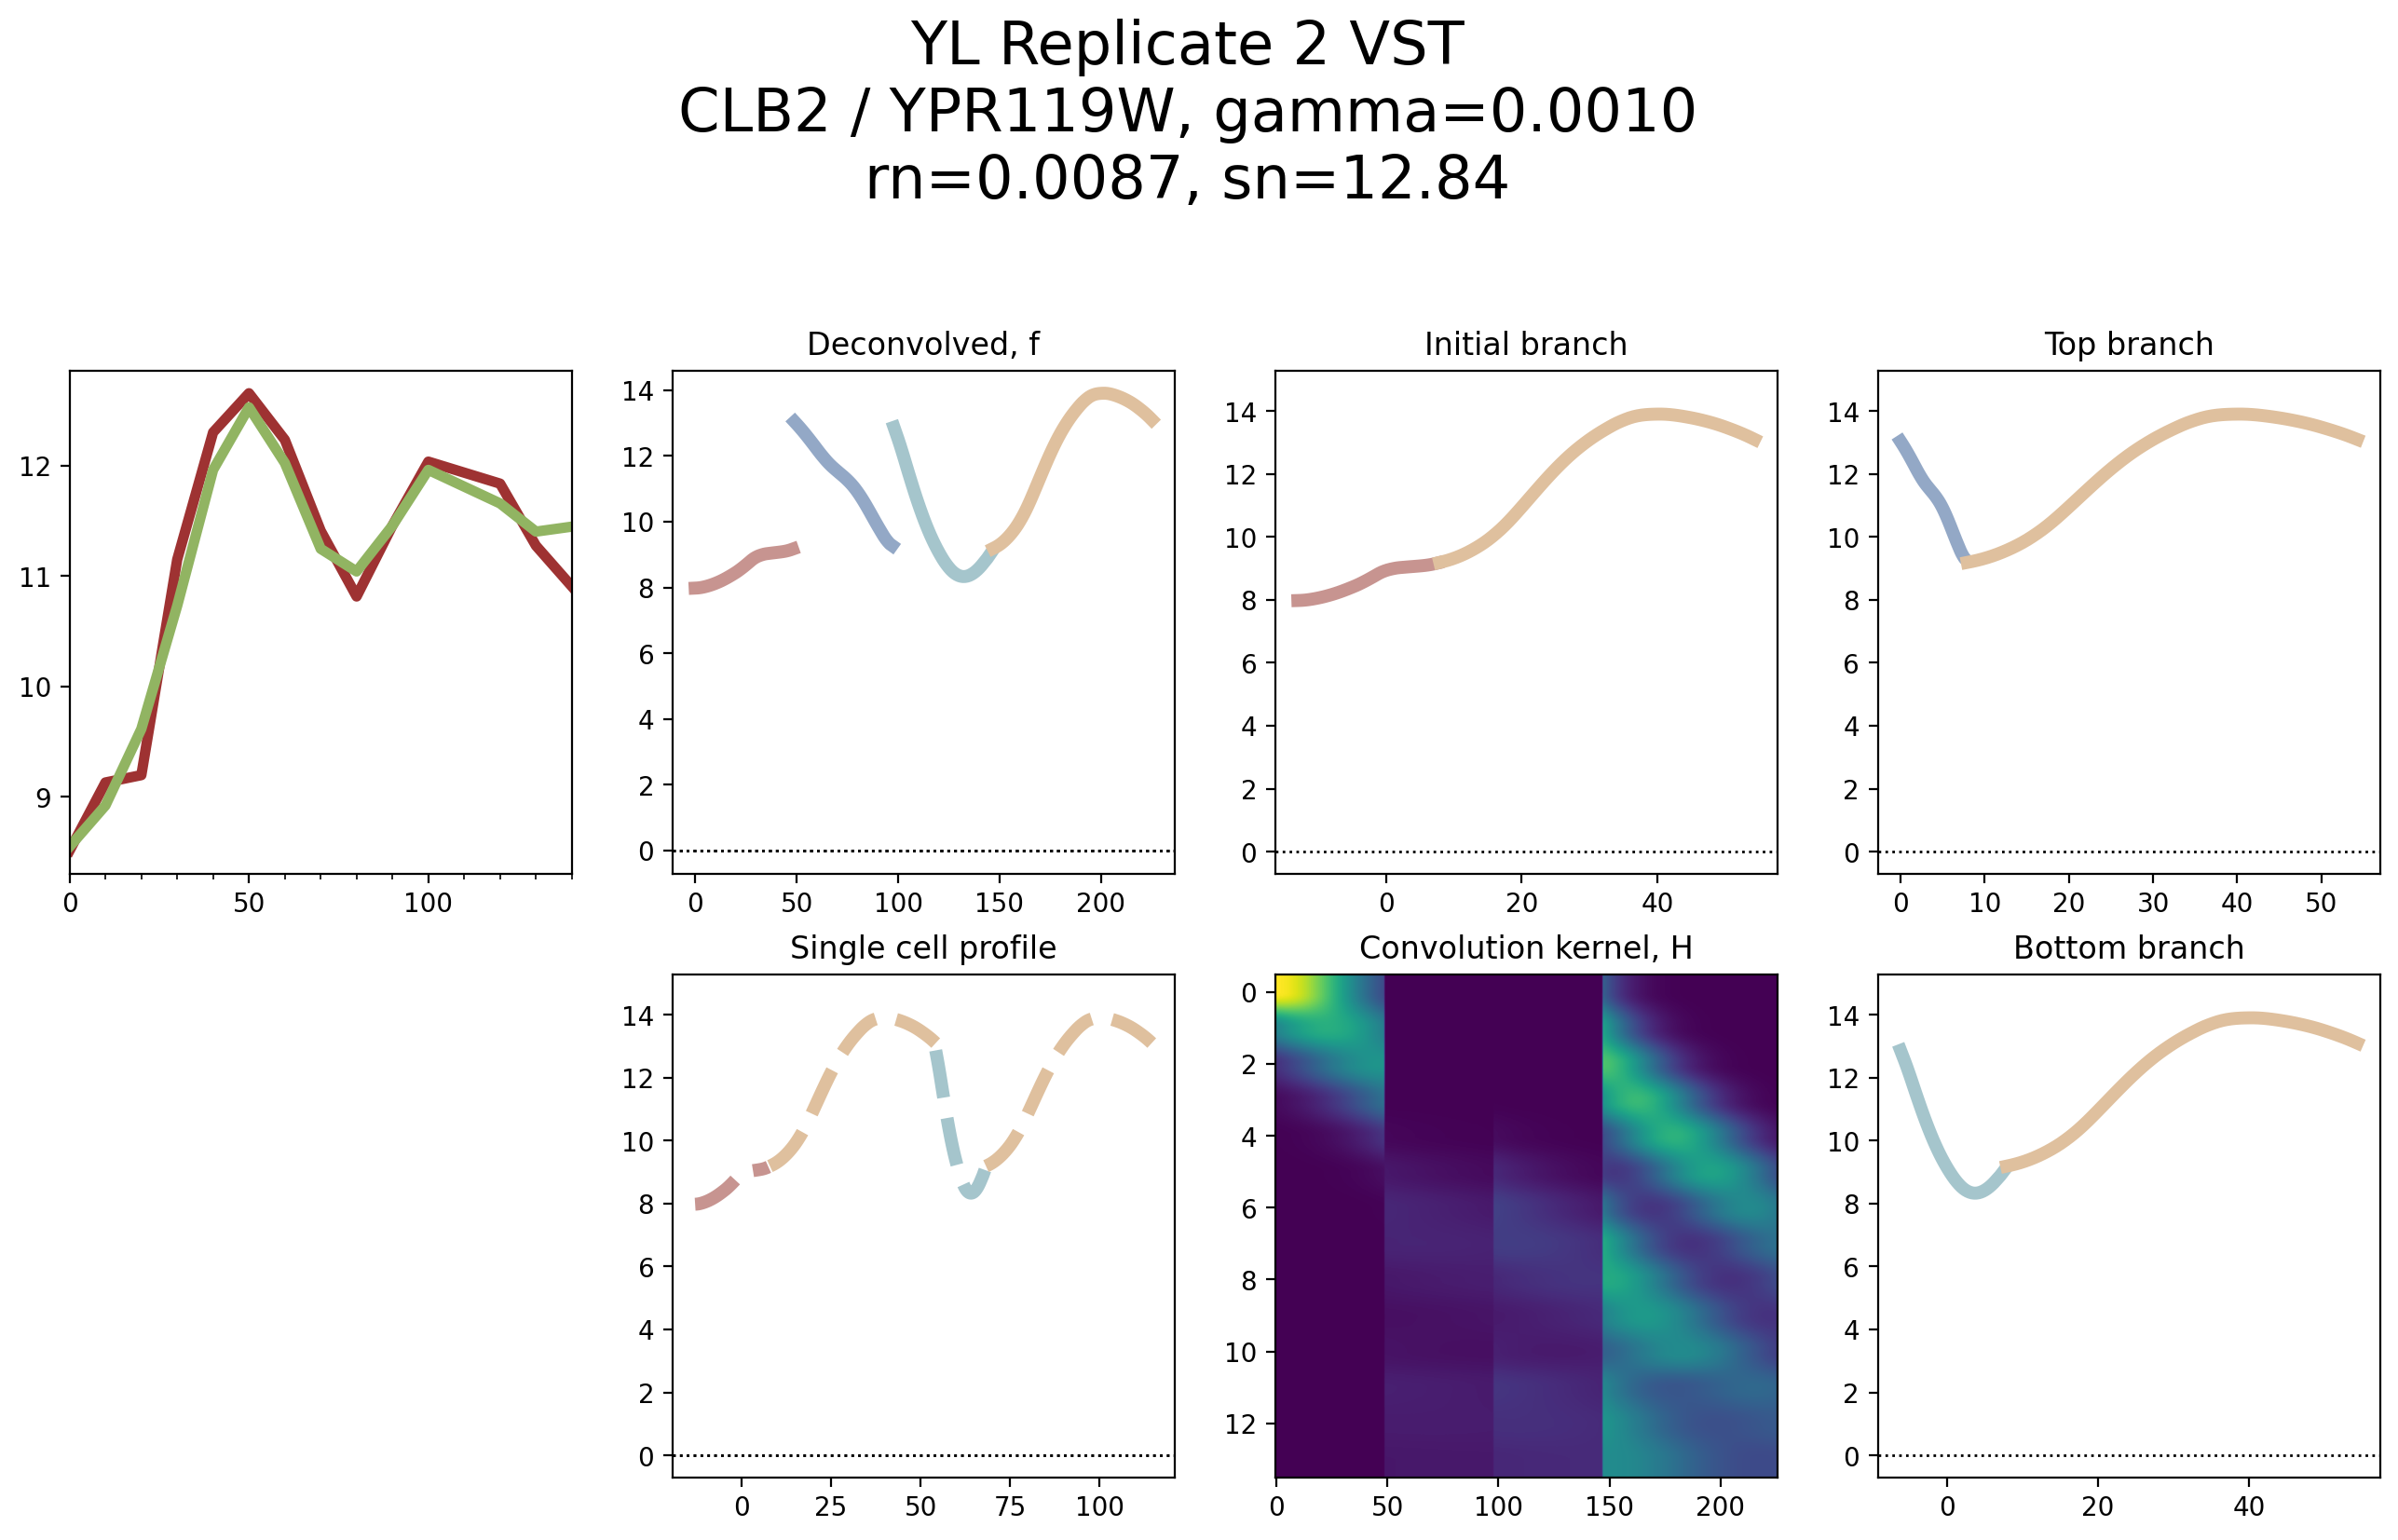

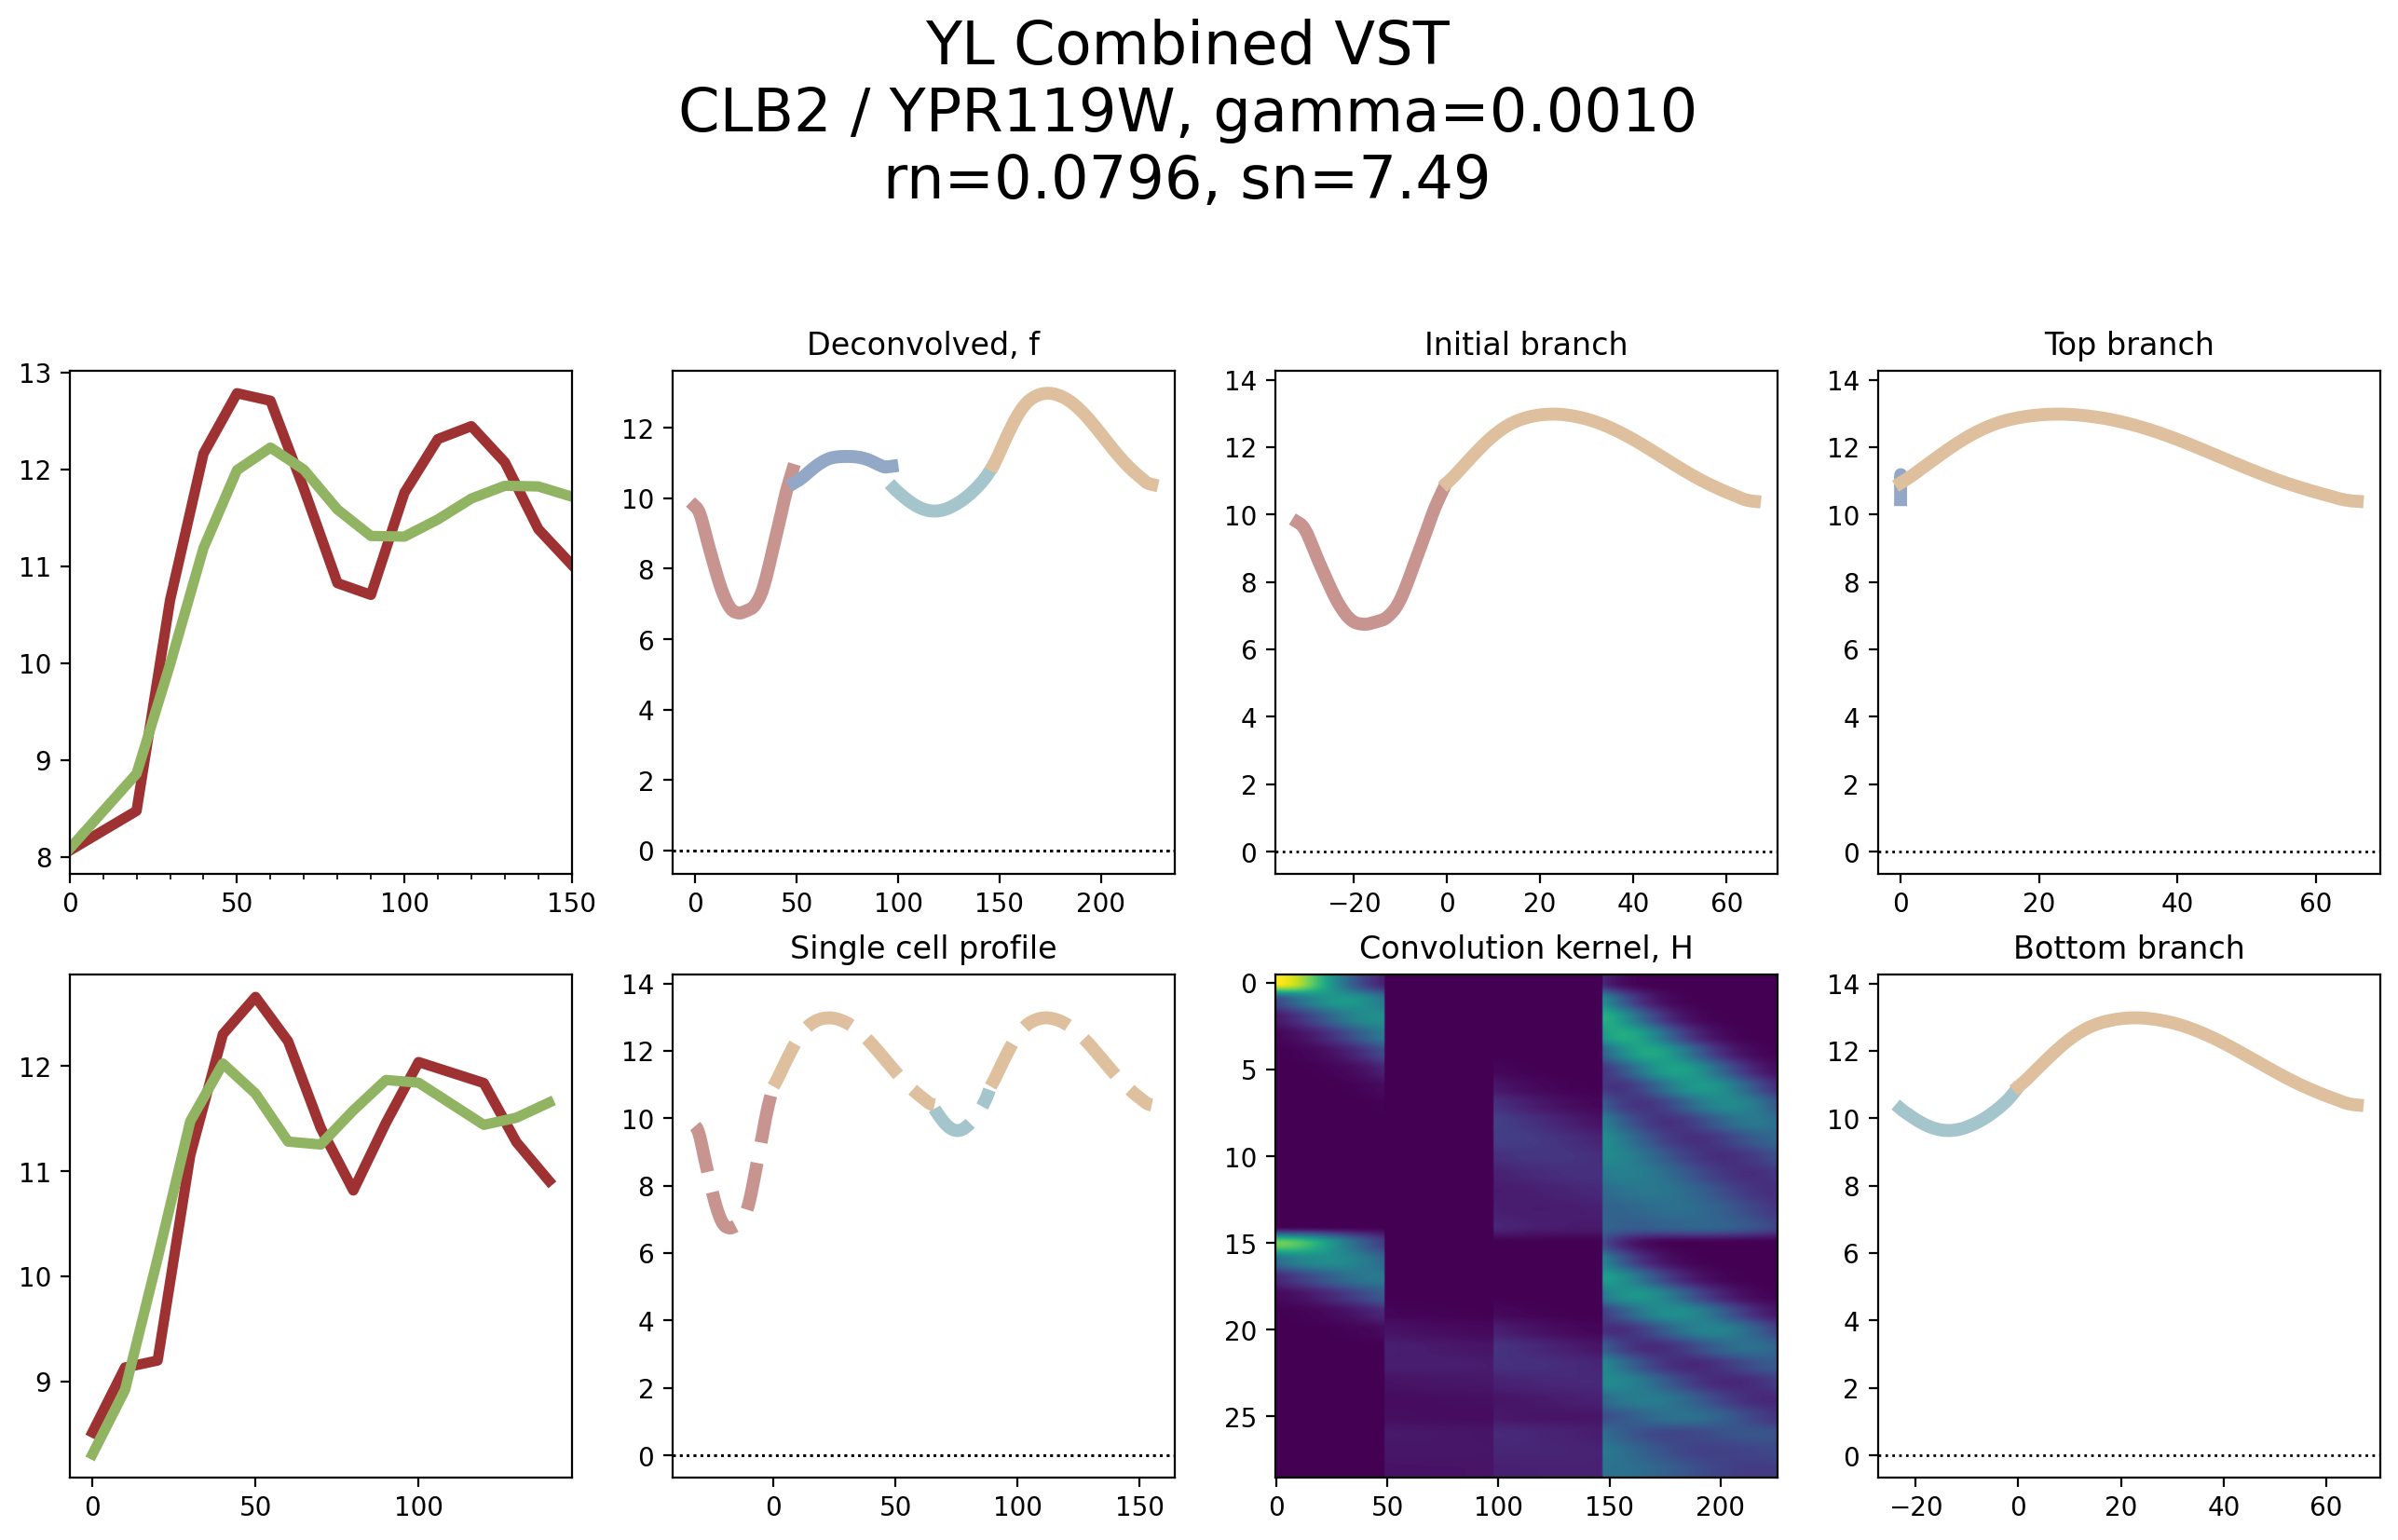

In [109]:
gene_name = "CLB2"

ge_model1 = plot_and_save_model_config(gene_name, config1, 'Replicate 1', 
                                       gamma=None)
ge_model2 = plot_and_save_model_config(gene_name, config2, 'Replicate 2',
                                       gamma=None)
ge_model_combined = plot_and_save_model_config(gene_name, config_combined, 
                                               'Combined', gamma=None)